# Phân tích Khám phá Dữ liệu Churn (EDA) - Bộ dữ liệu Sạch 2016-2019

Notebook này thực hiện phân tích trên file `gym_churn_master_final.csv` sau khi đã được làm sạch và xử lý lỗi nhân bản.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cấu hình hiển thị
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Tải và Kiểm tra Dữ liệu

In [2]:
df = pd.read_csv('../dataMaster/gym_churn_master_final.csv')
print(f"Kích thước dữ liệu: {df.shape}")
df.head()

Kích thước dữ liệu: (6327, 18)


,short_p_id,total_visits,max_streak,avg_time_lag,seniority_days,visits_per_month,recency,weekend_ratio,attendance_momentum,attendance_variance,is_churn,age,gender,main_density_class,customer_postal,att_rate,income,population_density_sq_mi
0,3,56.0,6.0,103.981859,881,1.904762,246,0.089286,1.000000,109.447844,1,43.0,F,1st Tier Suburban,92336,0.125805,107823.0,3951.1
1,33,294.0,5.0,4.770975,881,10.000000,246,0.020408,1.000000,8.826216,1,42.0,M,Super Urban,94619,0.315880,127507.0,1544.3
2,37,147.0,4.0,7.695201,770,5.719844,46,0.034014,0.333333,9.058065,0,28.0,F,1st Tier Suburban,92869,0.198718,138523.0,3980.1
3,44,52.0,1.0,32.139715,772,2.018111,355,0.250000,1.000000,39.624810,1,69.0,F,1st Tier Suburban,80923,0.189296,98212.0,4429.6
4,53,230.0,6.0,3.053272,656,10.502283,87,0.134783,1.000000,2.752254,1,69.0,M,Light Urban,90660,0.353030,80793.0,8129.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6327 entries, 0 to 6326
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   short_p_id                6327 non-null   int64  
 1   total_visits              6327 non-null   float64
 2   max_streak                6327 non-null   float64
 3   avg_time_lag              6327 non-null   float64
 4   seniority_days            6327 non-null   int64  
 5   visits_per_month          6327 non-null   float64
 6   recency                   6327 non-null   int64  
 7   weekend_ratio             6327 non-null   float64
 8   attendance_momentum       6327 non-null   float64
 9   attendance_variance       6327 non-null   float64
 10  is_churn                  6327 non-null   int64  
 11  age                       6327 non-null   float64
 12  gender                    6327 non-null   object 
 13  main_density_class        6250 non-null   object 
 14  customer

## 2. Phân tích Biến mục tiêu (is_churn)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29388\4219293381.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=df, palette='viridis')


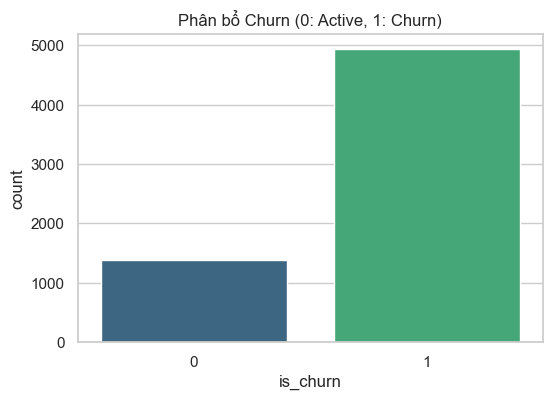

Tỷ lệ phần trăm:
is_churn
1    78.141299
0    21.858701
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_churn', data=df, palette='viridis')
plt.title('Phân bổ Churn (0: Active, 1: Churn)')
plt.show()

print("Tỷ lệ phần trăm:")
print(df['is_churn'].value_counts(normalize=True) * 100)

## 3. Phân tích các đặc trưng hành vi quan trọng

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29388\909362831.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29388\909362831.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29388\909362831.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churn', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp

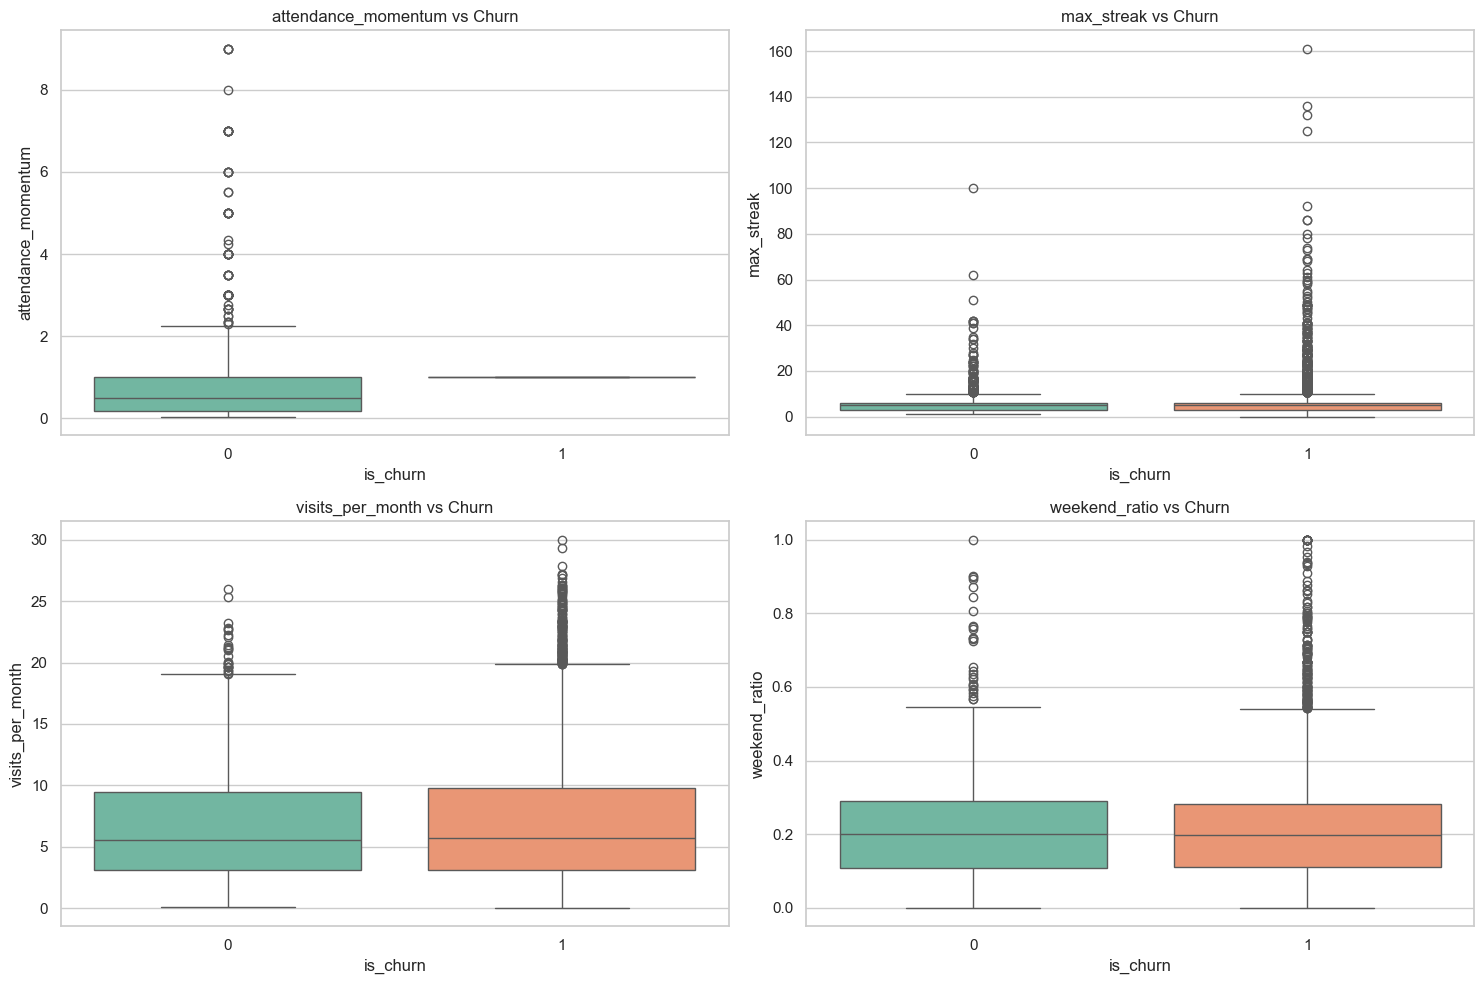

In [5]:
cols_to_plot = ['attendance_momentum', 'max_streak', 'visits_per_month', 'weekend_ratio']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='is_churn', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

## 4. Phân tích Nhân khẩu học và Kinh tế

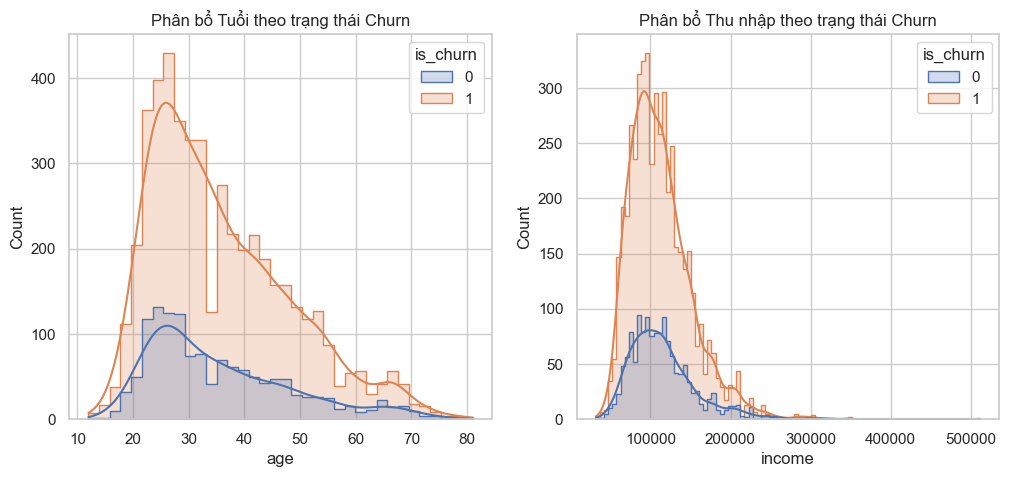

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='is_churn', kde=True, element="step")
plt.title('Phân bổ Tuổi theo trạng thái Churn')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='income', hue='is_churn', kde=True, element="step")
plt.title('Phân bổ Thu nhập theo trạng thái Churn')
plt.show()

## 5. Ma trận tương quan (Correlation Matrix)

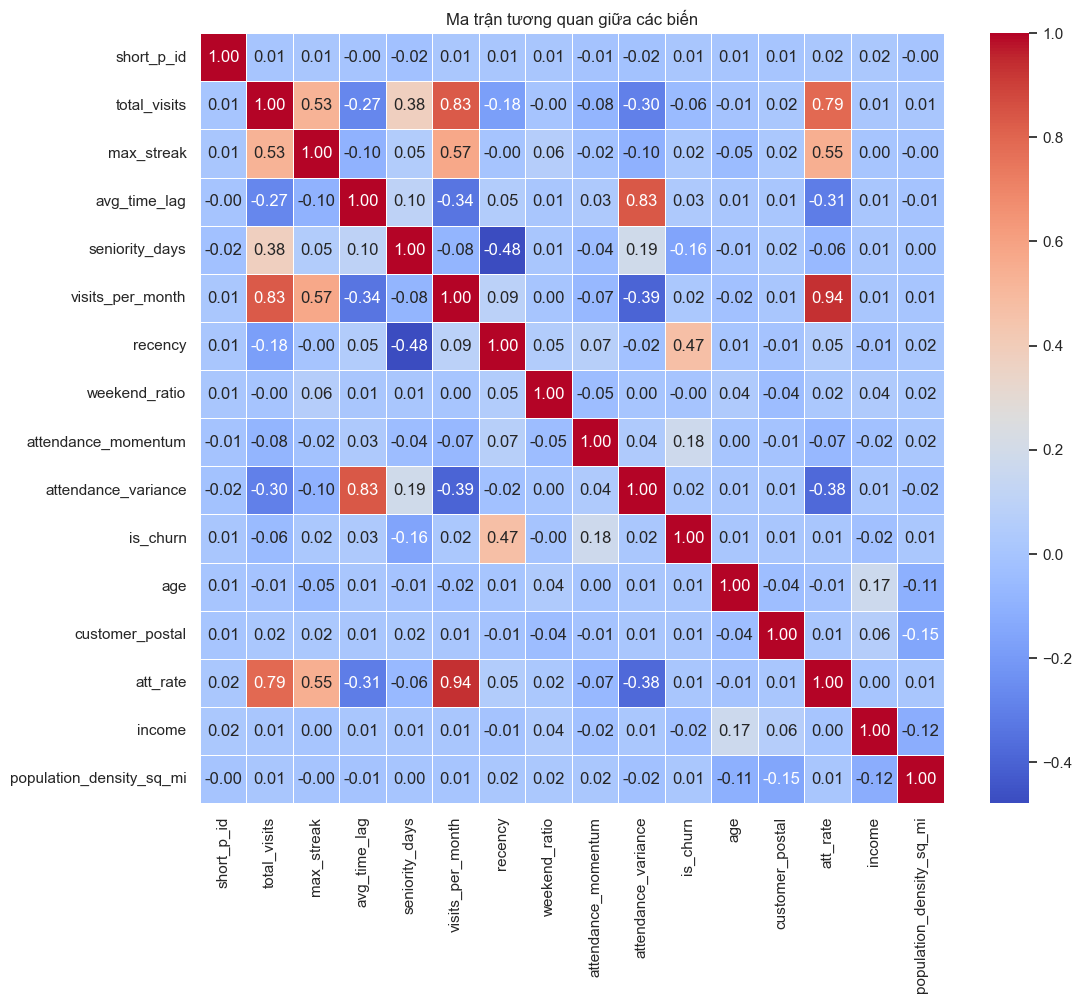

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến')
plt.show()

## 6. Tổng kết Nhận định

Dựa trên các biểu đồ trên, hãy ghi lại các quan sát quan trọng:
1. Biến nào có tương quan mạnh nhất với `is_churn`?
2. Nhóm học viên ở độ tuổi nào có tỷ lệ trung thành cao nhất?
3. Có dấu hiệu rõ rệt nào từ `attendance_momentum` trước khi khách hàng nghỉ không?